In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

First, loading in the various species and making a histogram of Tajima's D distributions.

In [27]:
df_l = []
for bed_path in glob.glob("../results/window_stats_20x_inds/*_100kb_10step_Tajima_D.bed"):
    long_form = bed_path.split("/")[-1].split("_100kb")[0]
    print(long_form)
    bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "Tajima_D"])
    bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
    bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)
    bed_df["species"] = long_form
    binned_and_filtered = bed_df.loc[(bed_df.callable_frac >= 0.5)].copy()
    binned_and_filtered["bins"] = pd.cut(binned_and_filtered.window_start,
                                     bins=np.arange(0, binned_and_filtered.window_start.max(), 100000))
    binned_and_filtered = binned_and_filtered.groupby(["species", "chr_type", "chrom", "bins"], observed=True)[["window_start", "Tajima_D", "callable_frac"]].mean().reset_index()
    df_l.append(binned_and_filtered)
bed_df_all = pd.concat(df_l)

Daubentonia_madagascariensis_ssp
Cercopithecus_mona_ssp
Hoolock_hoolock_ssp
Cheracebus_lugens_ssp
Papio_papio_ssp
Cercocebus_atys_ssp
Papio_cynocephalus_ssp
Macaca_arctoides_ssp
Aotus_nancymaae_ssp
Propithecus_coquereli_ssp
Aotus_azarai_ssp
Chiropotes_israelita_ssp
Cacajao_ayresi_ssp
Sapajus_apella_ssp
Macaca_maura_ssp
Trachypithecus_poliocephalus_ssp
Macaca_tonkeana_ssp
Macaca_radiata_ssp
Pongo_abelii_ssp
Alouatta_seniculus_ssp
Eulemur_flavifrons_ssp
Cheracebus_lucifer_ssp
Microcebus_murinus_ssp
Chiropotes_sagulatus_ssp
Macaca_fascicularis_ssp
Macaca_nigra_ssp
Pygathrix_nemaeus_ssp
Macaca_fuscata_ssp
Eulemur_collaris_ssp
Papio_hamadryas_ssp
Macaca_leonina_ssp
Papio_anubis_ssp
Pan_troglodytes_ssp
Cacajao_calvus_ssp
Semnopithecus_entellus_ssp
Ateles_chamek_ssp
Gorilla_gorilla_ssp
Macaca_mulatta_ssp
Macaca_silenus_ssp
Papio_ursinus_ssp
Nycticebus_bengalensis_ssp
Saimiri_boliviensis_ssp
Callithrix_jacchus_ssp
Trachypithecus_francoisi_ssp
Gorilla_beringei_ssp
Alouatta_macconnelli_ssp
Pongo

In [32]:
binned_and_filtered

,species,chr_type,chrom,bins,window_start,Tajima_D,callable_frac
0,Pan_paniscus_ssp,aut,NC_073249.2,"(0, 100000]",95000.0,-0.237953,0.60865
1,Pan_paniscus_ssp,aut,NC_073249.2,"(100000, 200000]",155000.0,0.109353,0.91703
2,Pan_paniscus_ssp,aut,NC_073249.2,"(200000, 300000]",255000.0,1.027851,0.96470
3,Pan_paniscus_ssp,aut,NC_073249.2,"(300000, 400000]",355000.0,1.154904,0.97258
4,Pan_paniscus_ssp,aut,NC_073249.2,"(400000, 500000]",455000.0,0.267049,0.93891
...,...,...,...,...,...,...,...
109147,Pan_paniscus_ssp,chrX,NC_085927.1,"(226900000, 227000000]",NaN,NaN,NaN
109148,Pan_paniscus_ssp,chrX,NC_085927.1,"(227000000, 227100000]",NaN,NaN,NaN
109149,Pan_paniscus_ssp,chrX,NC_085927.1,"(227100000, 227200000]",NaN,NaN,NaN
109150,Pan_paniscus_ssp,chrX,NC_085927.1,"(227200000, 227300000]",NaN,NaN,NaN


[Text(0.5, 1.0, 'ChrX Gorilla')]

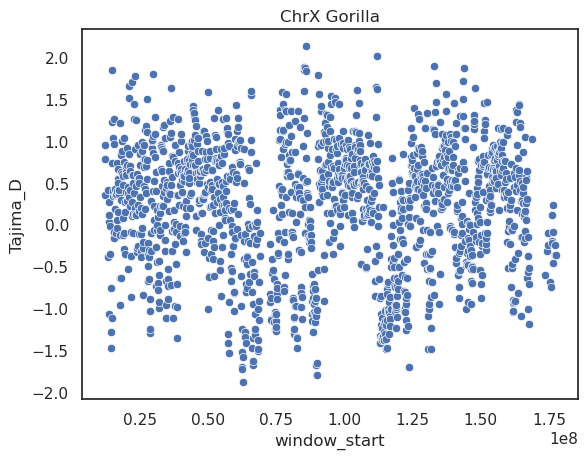

In [40]:
g = sns.scatterplot(bed_df_all.loc[(bed_df_all.species == "Gorilla_gorilla_ssp")
                               & (bed_df_all.chr_type == "chrX")],
               x="window_start", y="Tajima_D")
g.set(title="ChrX Gorilla")

<Axes: xlabel='window_start', ylabel='Tajima_D'>

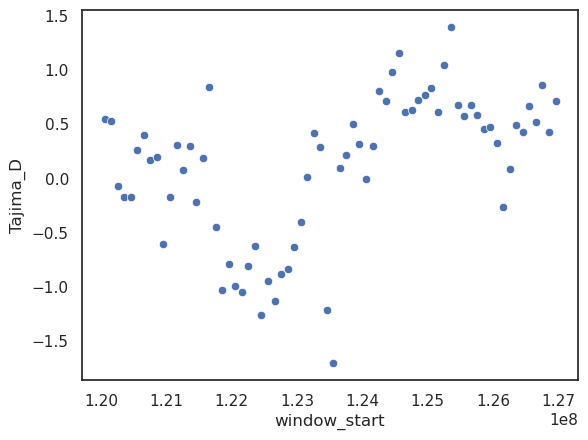

In [37]:
sns.scatterplot(bed_df_all.loc[(bed_df_all.species == "Gorilla_gorilla_ssp")
                               & (bed_df_all.chr_type == "chrX")
                               & (bed_df_all.window_start >= 120000000)
                               & (bed_df_all.window_start <= 127000000)],
               x="window_start", y="Tajima_D")

/tmp/35042620/ipykernel_1743099/1570637438.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


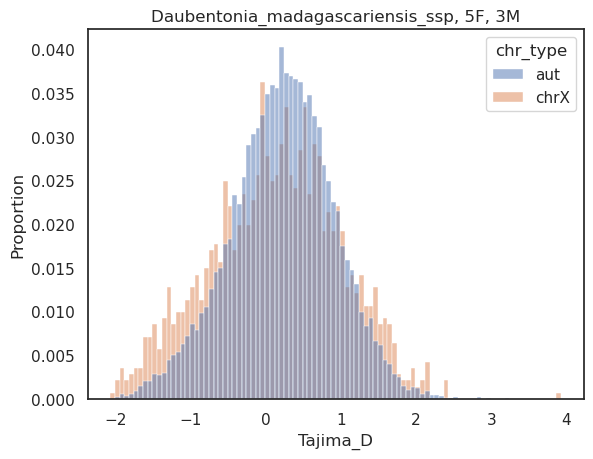

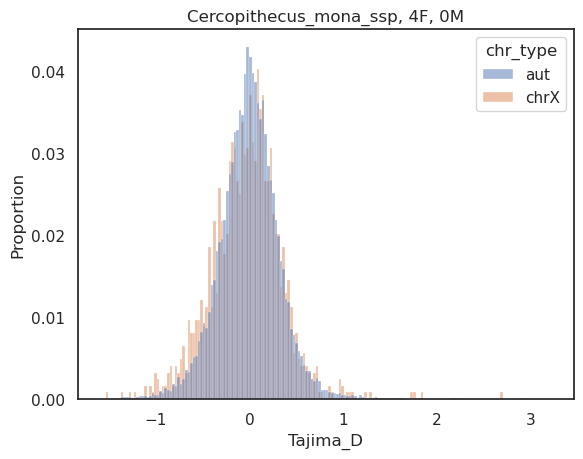

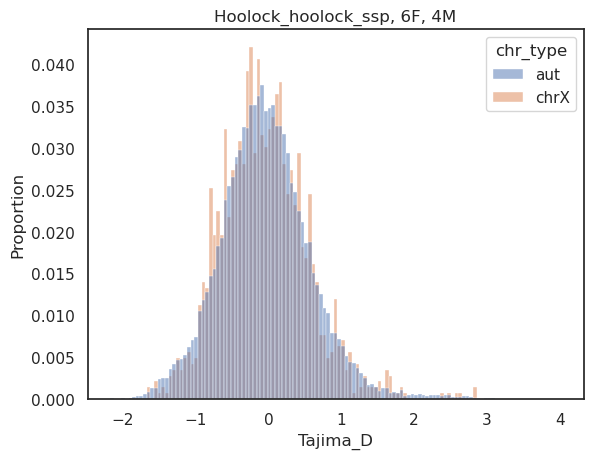

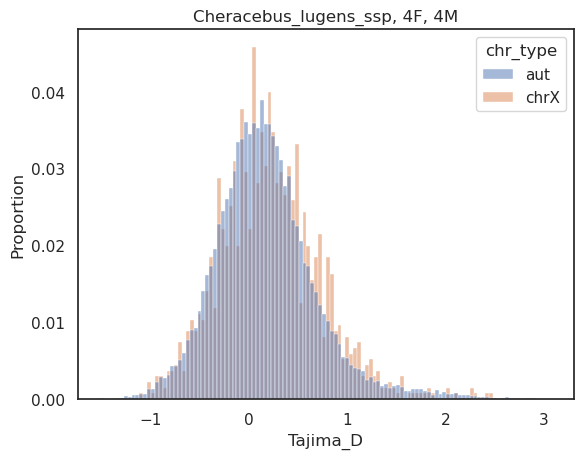

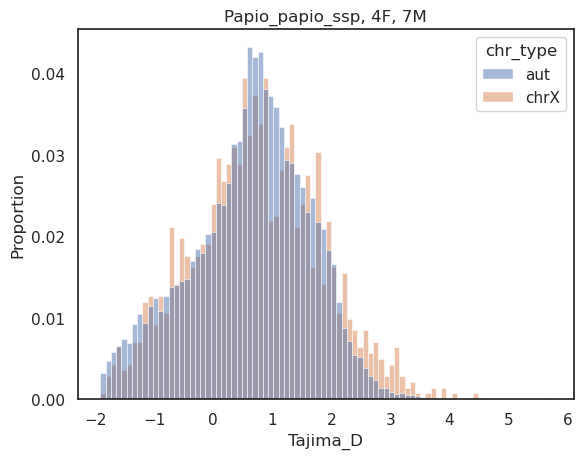

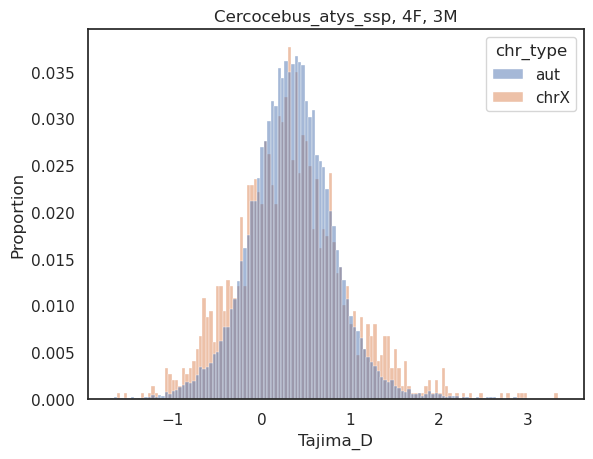

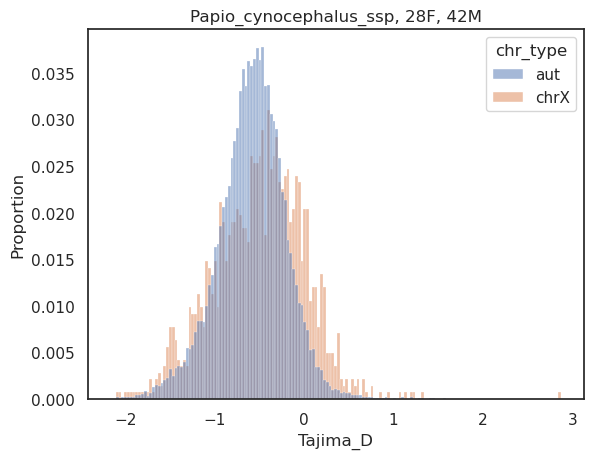

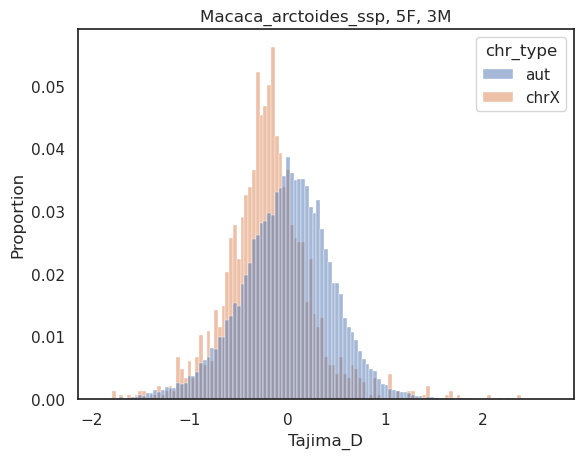

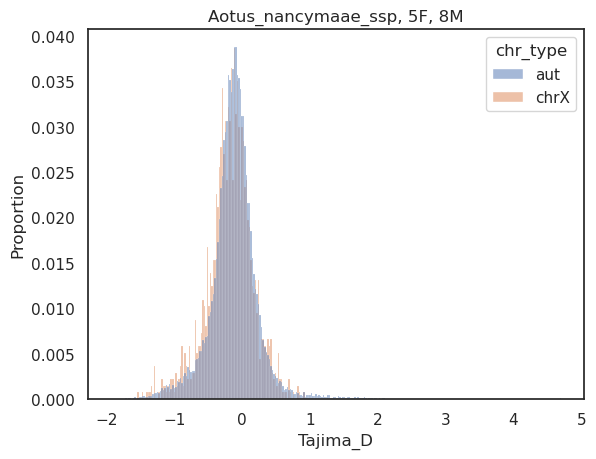

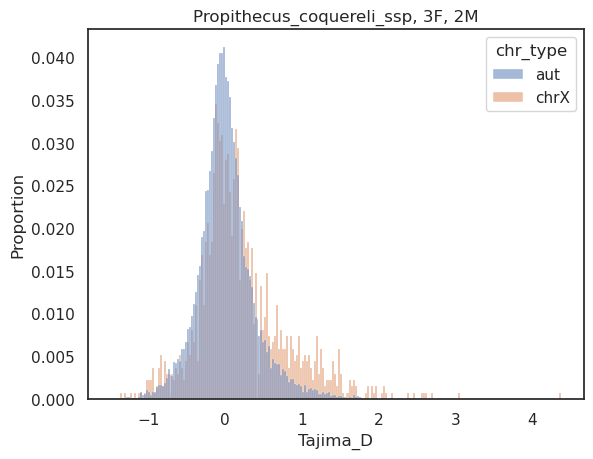

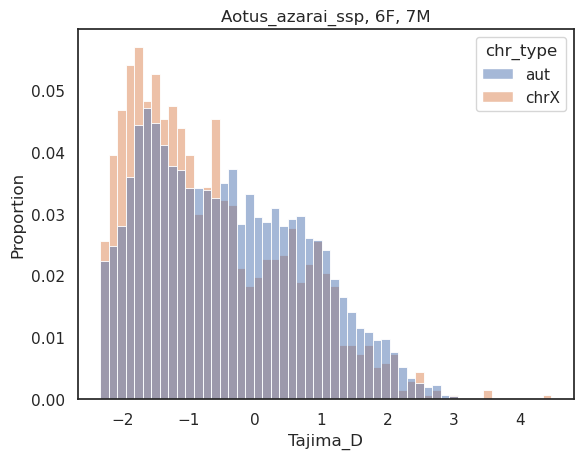

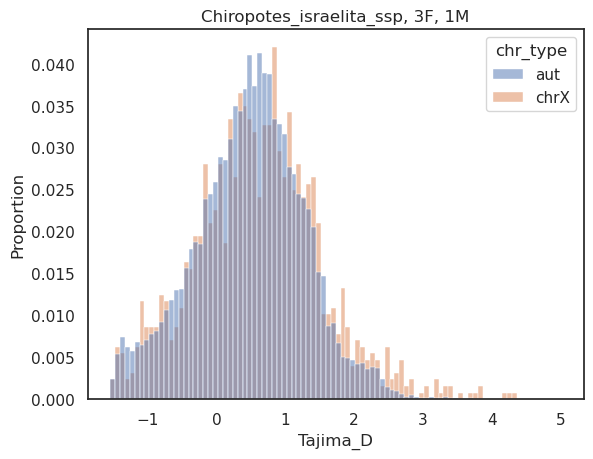

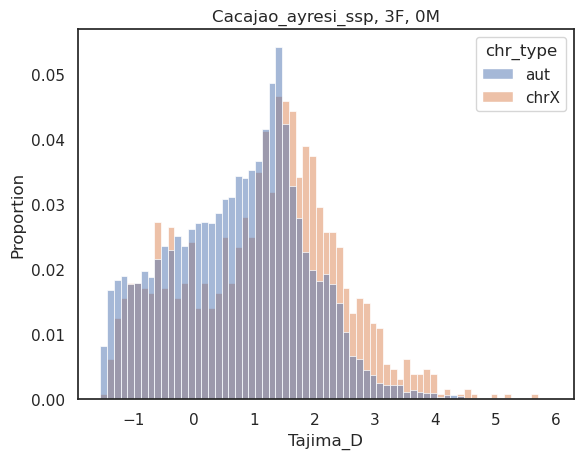

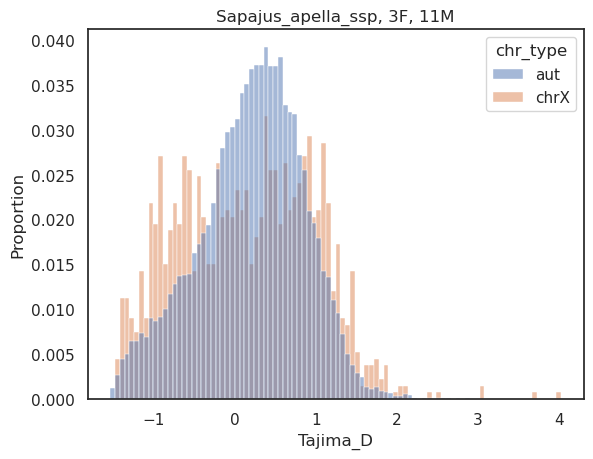

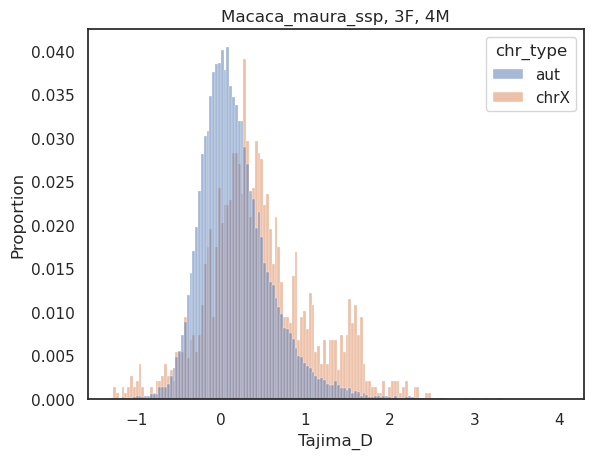

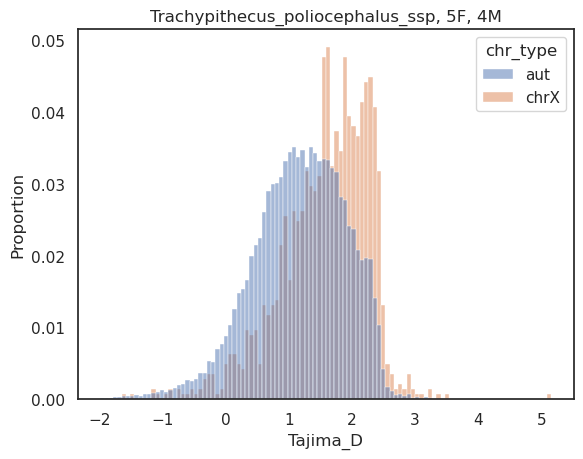

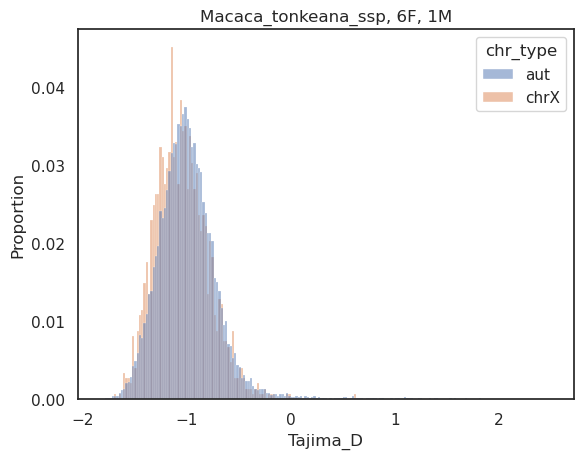

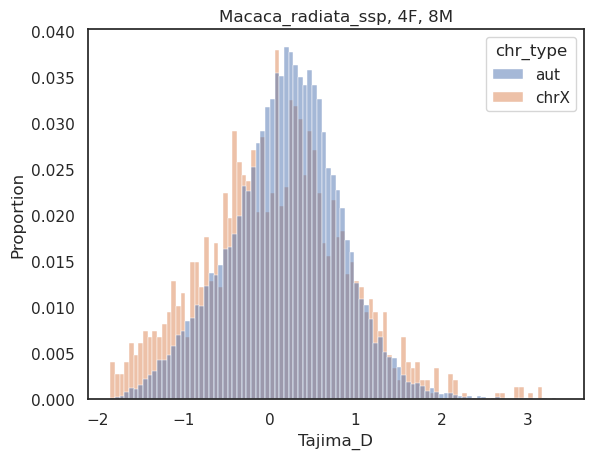

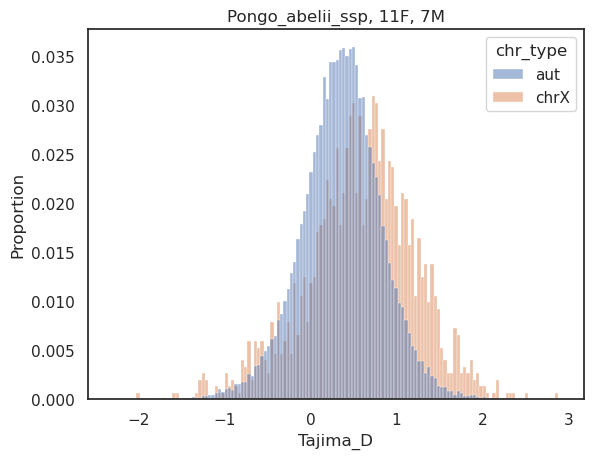

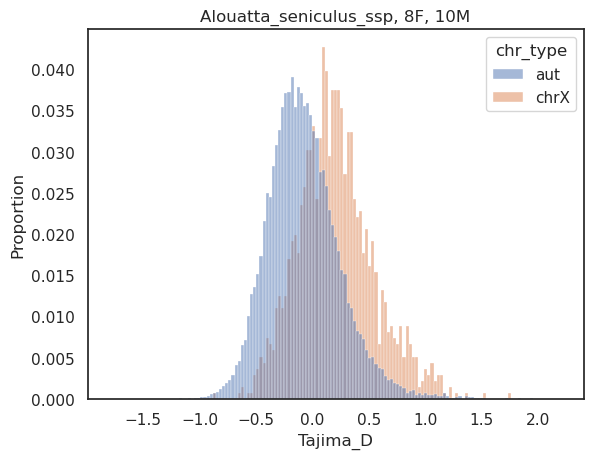

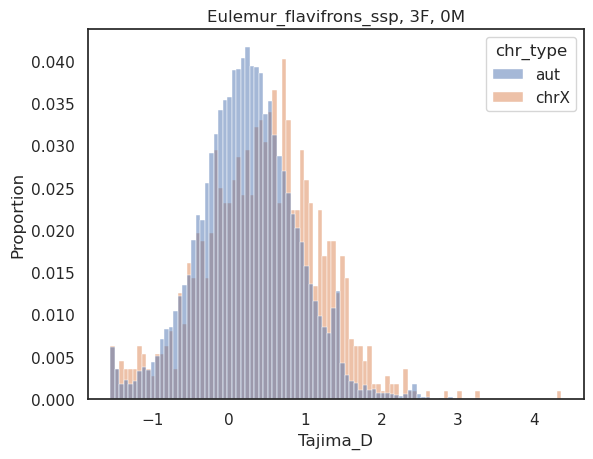

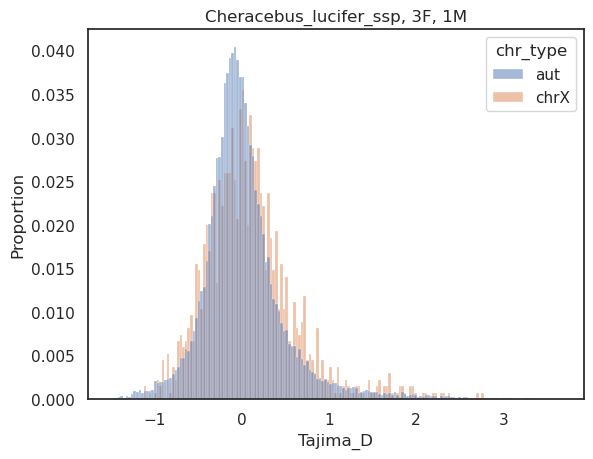

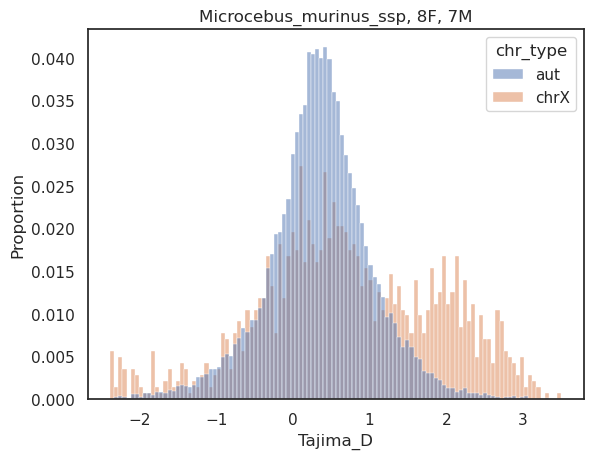

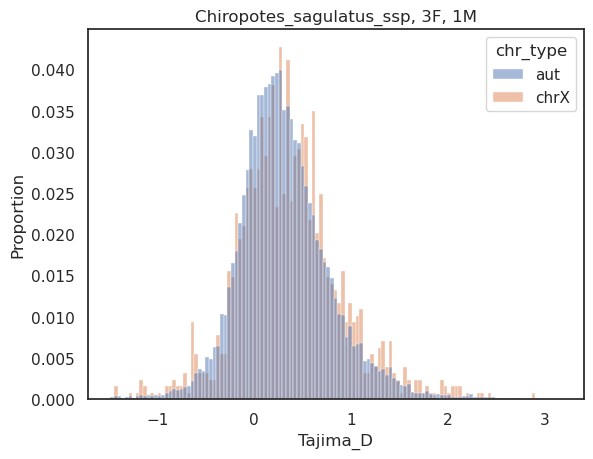

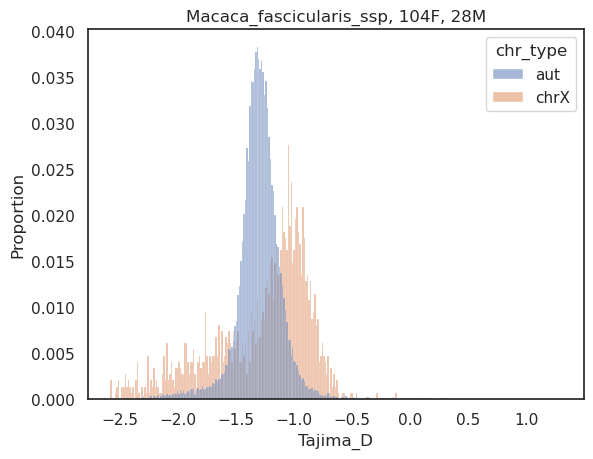

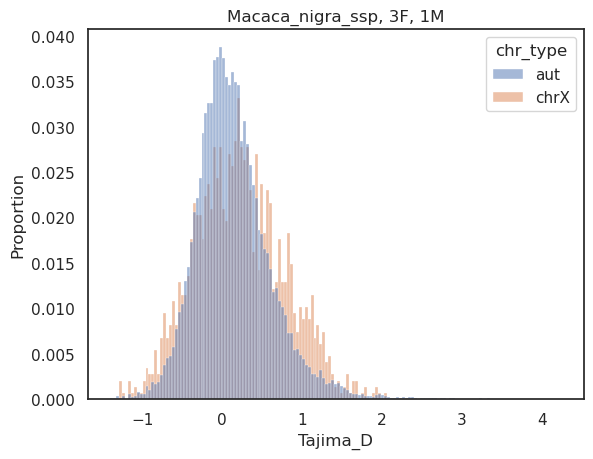

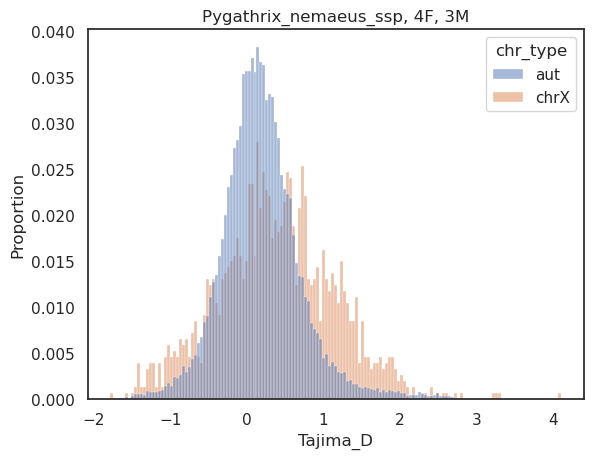

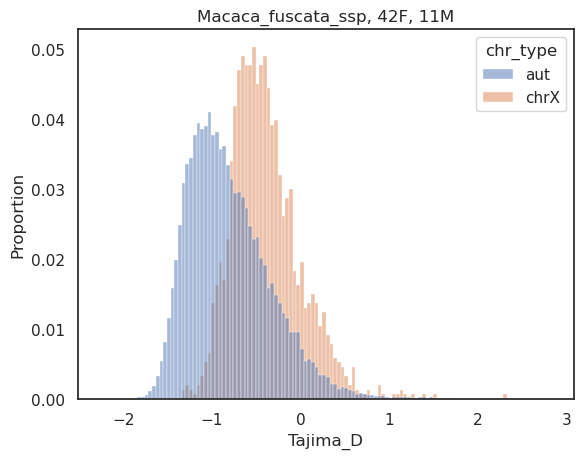

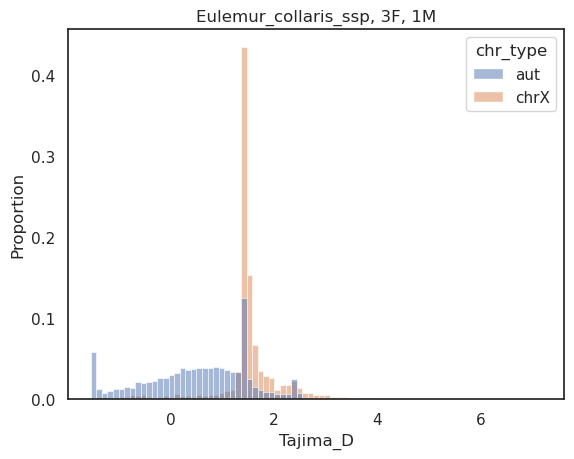

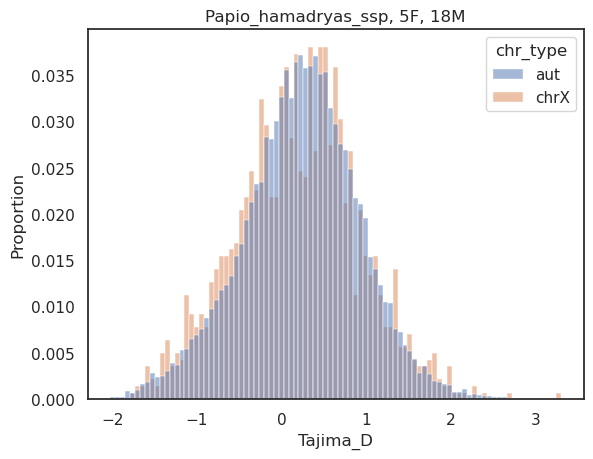

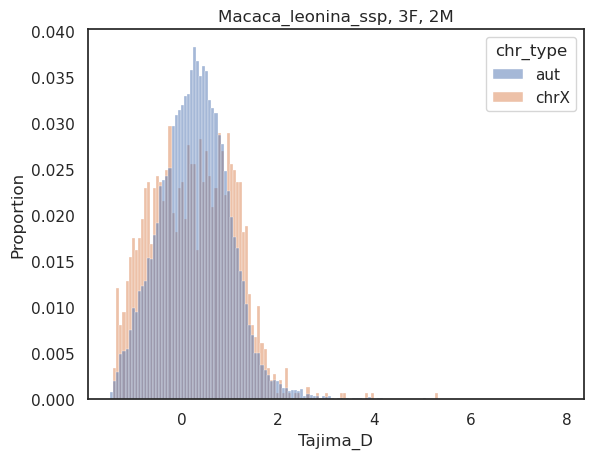

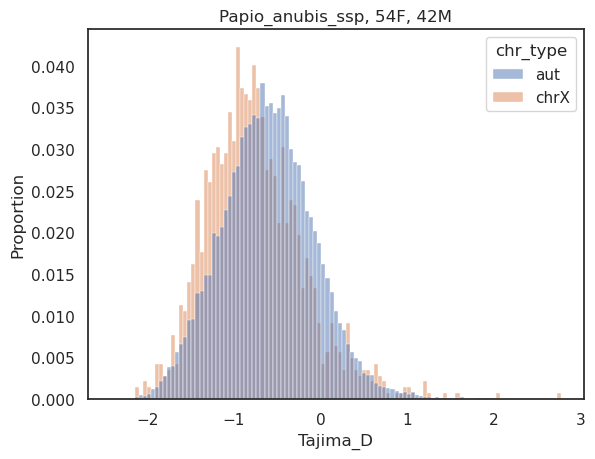

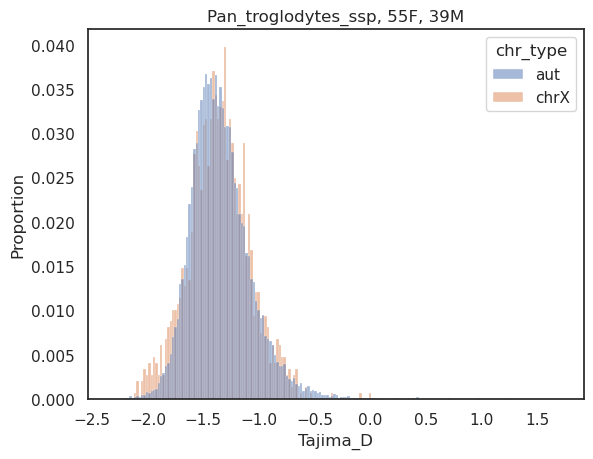

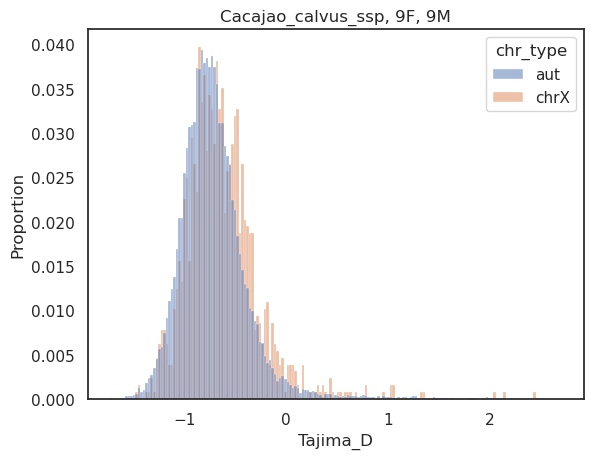

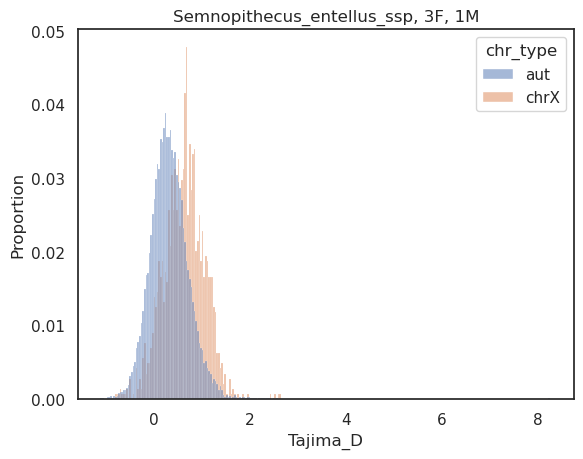

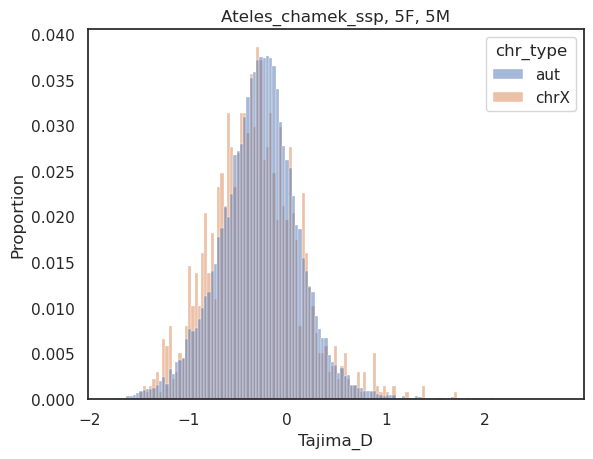

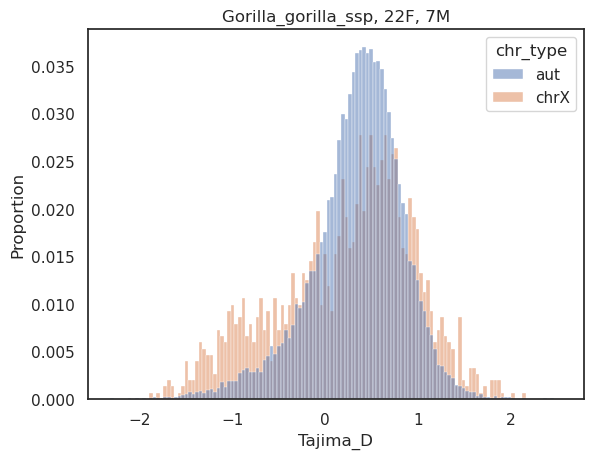

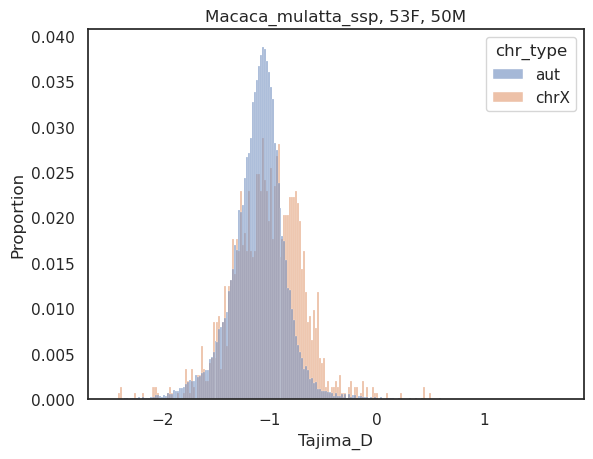

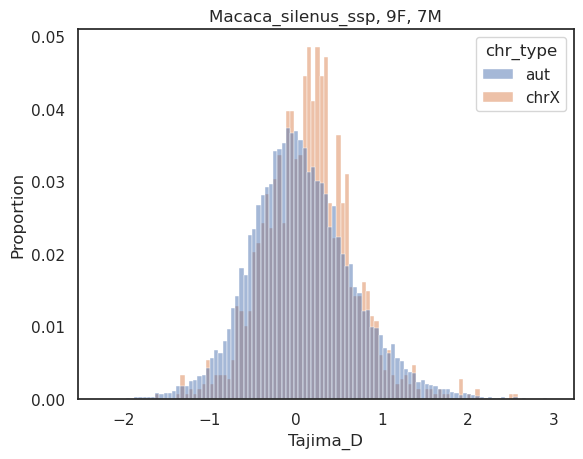

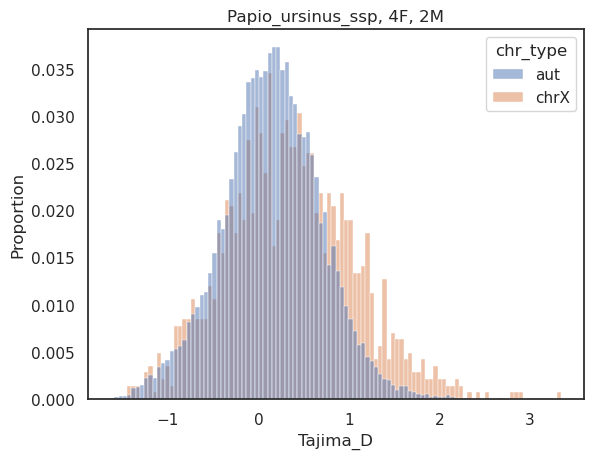

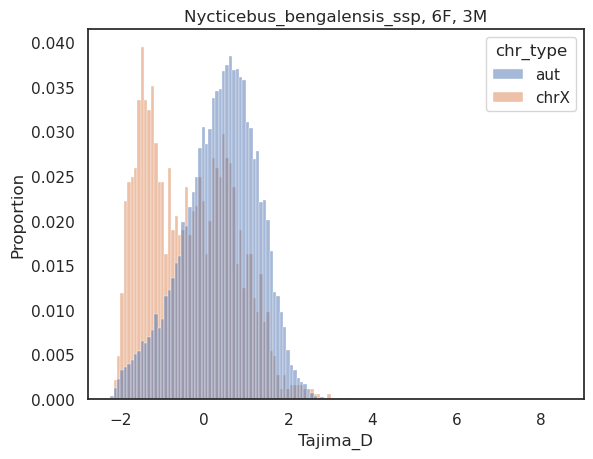

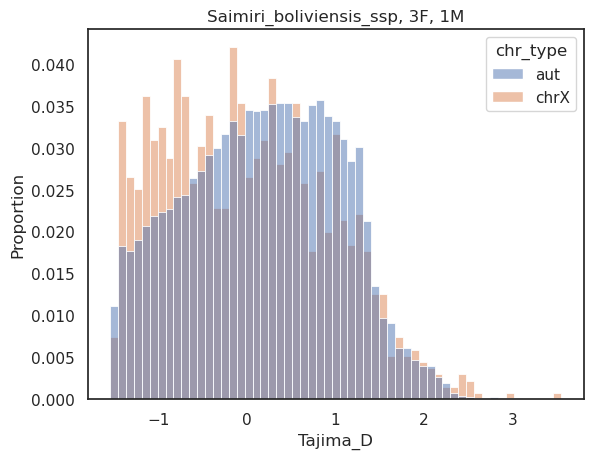

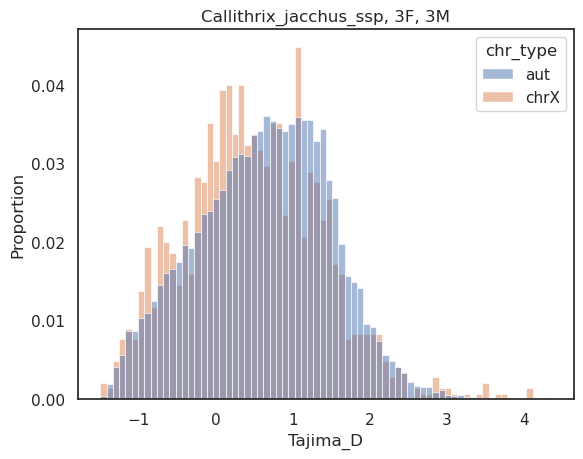

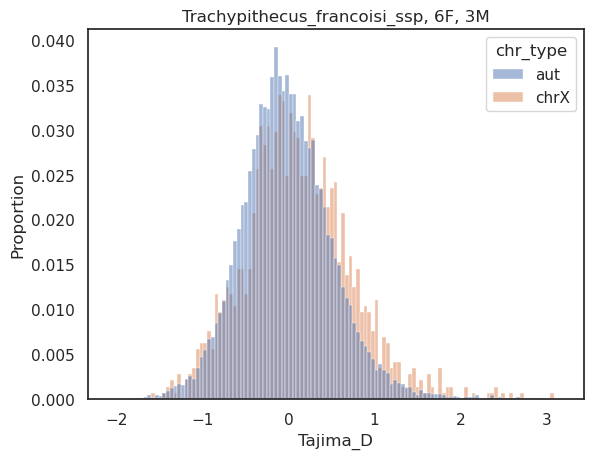

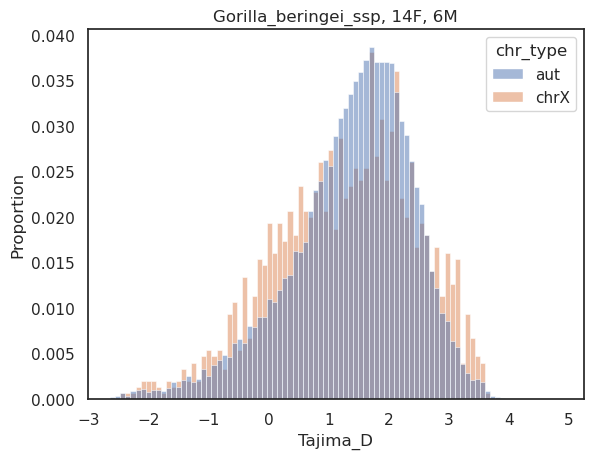

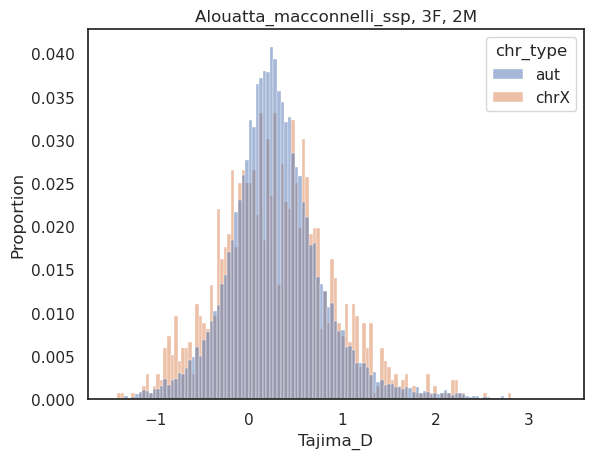

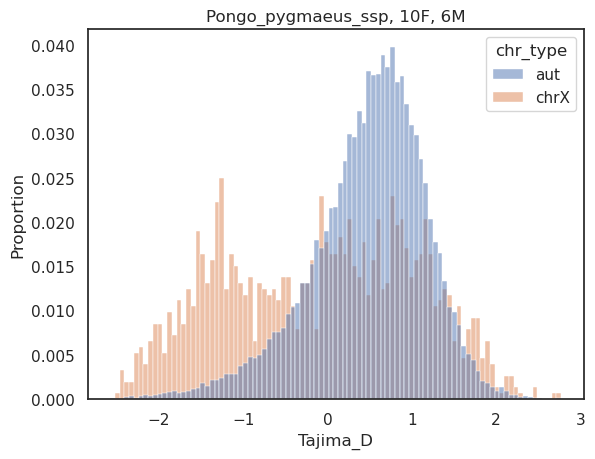

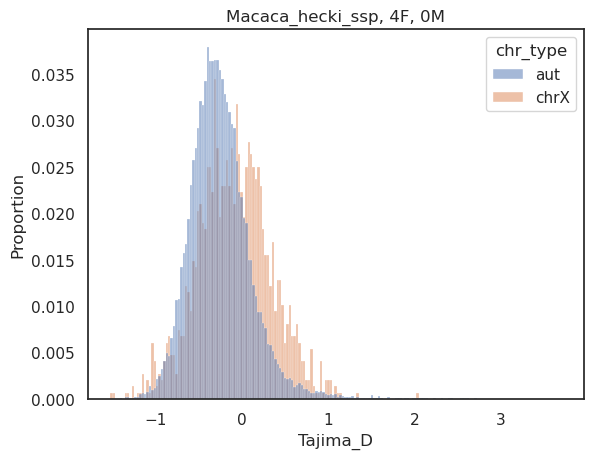

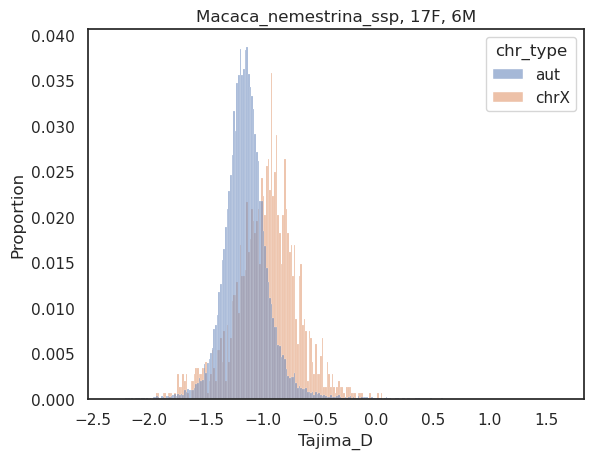

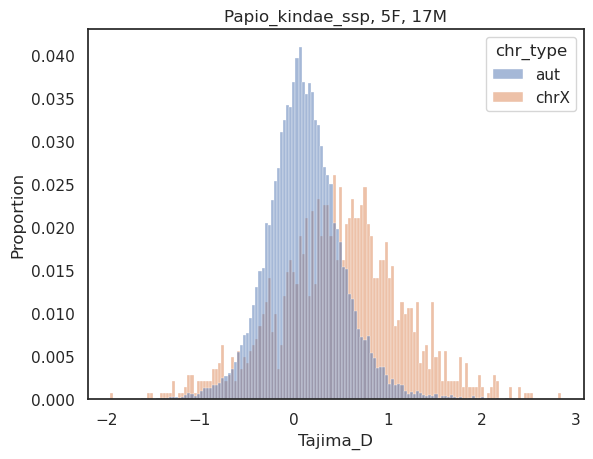

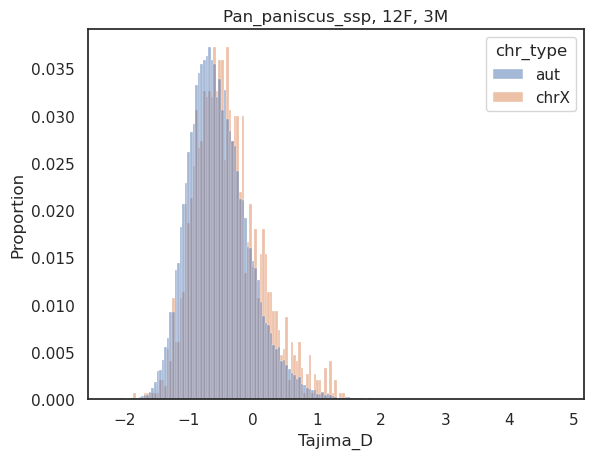

<Figure size 640x480 with 0 Axes>

In [38]:
for s in bed_df_all.species.unique()[:]:
    g = sns.histplot(bed_df_all.loc[(bed_df_all.species == s)], x="Tajima_D", hue="chr_type",
             stat="proportion", common_norm=False)
    female_count = len(metadata_20x_filt.loc[(metadata_20x_filt.species_genotyping == s)
                                          & (metadata_20x_filt.gSEX == "F")])
    male_count = len(metadata_20x_filt.loc[(metadata_20x_filt.species_genotyping == s)
                                          & (metadata_20x_filt.gSEX == "M")])
    g.set(title="{}, {}F, {}M".format(s, female_count, male_count))
    plt.figure()